# Evaluación Parcial N°2 – Near Earth Objects (NEO)

**Docente**: Mariela Moraga

**Ramo**: Programación para la Ciencia de Datos (SCY1101)  

**Sección**: 002D

**Estudiante**: Milenka Guerra

**Dataset**: `neo.csv`

---

## 0. Importaciones y Configuración Global

Se importan las librerías necesarias para el flujo completo de análisis y modelado. Las configuraciones visuales y de display se establecen de forma centralizada antes de cargar cualquier dato, garantizando consistencia estética y numérica en todo el proyecto.

In [2]:
# Manejo de Datos
import os

os.environ["PYTHONWARNINGS"] = "ignore"
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocesamiento y partición
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
)

# Modelos supervisados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Modelos no supervisados
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
)

# Evitar warnings en funciones obsoletas
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module="pkg_resources")

# Configuraciones globales
SEED = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

## 1. Carga e Inspección Inicial

In [3]:
# Carga datos
df = pd.read_csv("../data/raw/neo.csv")

# Revisión inicial
print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

Dimensiones: 90836 filas y 10 columnas


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.1983,2.6794,"13,569.2492","54,839,744.0828",Earth,False,16.7300,False
1,2277475,277475 (2005 WK4),0.2658,0.5943,"73,588.7267","61,438,126.5240",Earth,False,20.0000,True
2,2512244,512244 (2015 YE18),0.7220,1.6145,"114,258.6921","49,798,724.9405",Earth,False,17.8300,False
3,3596030,(2012 BV13),0.0965,0.2158,"24,764.3031","25,434,972.7208",Earth,False,22.2000,False
4,3667127,(2014 GE35),0.2550,0.5702,"42,737.7338","46,275,567.0013",Earth,False,20.0900,True


### 1.1 Contexto del Dataset

El dataset proviene de registros de la NASA sobre **Near Earth Objects (NEO)**, que estudia cuerpos del sistema solar cuya órbita los acerca a la Tierra. Contiene 90.836 observaciones de asteroides con las siguientes variables:

| Variable | Tipo | Descripción |
|-|-|-|
| `id` | Identificador | Código único del objeto en la base de datos |
| `name` | Identificador | Designación oficial del asteroide |
| `est_diameter_min` | Numérica | Diámetro mínimo estimado (km) |
| `est_diameter_max` | Numérica | Diámetro máximo estimado (km) |
| `relative_velocity` | Numérica | Velocidad relativa respecto a la Tierra (km/s) |
| `miss_distance` | Numérica | Distancia mínima de aproximación a la Tierra (km) |
| `orbiting_body` | Categórica | Cuerpo alrededor del cual orbita el objeto |
| `sentry_object` | Booleana | Si el objeto está en el sistema Sentry de monitoreo de impacto |
| `absolute_magnitude` | Numérica | Brillo intrínseco del asteroide |
| `hazardous` | Booleana | Si el asteroide es potencialmente peligroso — **variable objetivo** |

El problema es predecir si un asteroide es peligroso o no a partir de sus características físicas y orbitales.

### 1.2 Estructura e Integridad del Dataset

In [4]:
# Estructura del DataFrame
tabla_estructura = pd.DataFrame(
    {
        "Tipo de Dato": df.dtypes.astype(str),
        "Valores Únicos": [df[col].nunique() for col in df.columns],
        "Datos Nulos (NaN)": df.isnull().sum(),
    }
)

display(tabla_estructura)

,Tipo de Dato,Valores Únicos,Datos Nulos (NaN)
id,int64,27423,0
name,str,27423,0
est_diameter_min,float64,1638,0
est_diameter_max,float64,1638,0
relative_velocity,float64,90828,0
miss_distance,float64,90536,0
orbiting_body,str,1,0
sentry_object,bool,1,0
absolute_magnitude,float64,1638,0
hazardous,bool,2,0


- El dataset está completo, ya que no se registran valores nulos formales.
- Tanto `orbiting_body` como `sentry_object` tienen un solo valor único. Y en conjunto a `id` y `name` (identificadores) son columnas que no aportan variabilidad. Por lo mismo, se eliminarán en procesos futuros.

In [5]:
# Estadísticas descriptivas
columnas_num = df.select_dtypes(include="number").columns.drop("id")

estadisticas = pd.DataFrame(
    {
        "Media": df[columnas_num].mean(),
        "Mediana": df[columnas_num].median(),
        "Desv. Estándar": df[columnas_num].std(),
        "Mínimo": df[columnas_num].min(),
        "Q1": df[columnas_num].quantile(0.25),
        "Q3": df[columnas_num].quantile(0.75),
        "Máximo": df[columnas_num].max(),
        "IQR": df[columnas_num].quantile(0.75) - df[columnas_num].quantile(0.25),
    }
)

display(estadisticas.round(2))

,Media,Mediana,Desv. Estándar,Mínimo,Q1,Q3,Máximo,IQR
est_diameter_min,0.1300,0.0500,0.3000,0.0000,0.0200,0.1400,37.8900,0.1200
est_diameter_max,0.2800,0.1100,0.6700,0.0000,0.0400,0.3200,84.7300,0.2800
relative_velocity,"48,066.9200","44,190.1200","25,293.3000",203.3500,"28,619.0200","62,923.6000","236,990.1300","34,304.5800"
miss_distance,"37,066,546.0300","37,846,579.2600","22,352,040.6000","6,745.5300","17,210,820.2400","56,548,996.4500","74,798,651.4500","39,338,176.2200"
absolute_magnitude,23.5300,23.7000,2.8900,9.2300,21.3400,25.7000,33.2000,4.3600


- `est_diameter_min` y `est_diameter_max` tienen mediana muy baja (0.05 y 0.11 km) pero máximos de 37.89 y 84.73 km respectivamente. Por lo que podemos inferir que la mayoría de los asteroides son pequeños, pero hay valores extremos que van a afectar la distribución.

- `relative_velocity` muestra un rango de 203 a 236.990 km/s con un IQR de 34.304, por lo tanto, se puede asumir que hay dispersión real y no solo outliers puntuales. Es decir, es una variable con variabilidad genuina.

- `miss_distance` tiene media y mediana cercanas (37M y 37.8M km), lo que sugiere una distribución relativamente simétrica a diferencia de las variables de diámetro.

- `absolute_magnitude` es la variable más estable del dataset con un IQR de 4.36 y una desviación estándar de 2.89. Su distribución parece ser la más concentrada de todas.

- Las diferencias en las escalas de las variables confirman que la estandarización es necesaria antes de entrenar cualquier modelo sensible a magnitudes.

In [6]:
# Tabla "hazardous"
conteo = df["hazardous"].value_counts()
proporciones = df["hazardous"].value_counts(normalize=True) * 100

resumen = pd.DataFrame({"Cantidad": conteo, "Porcentaje (%)": proporciones.round(1)})
resumen.index = ["No peligroso (False)", "Peligroso (True)"]

display(resumen)

,Cantidad,Porcentaje (%)
No peligroso (False),81996,90.3000
Peligroso (True),8840,9.7000


La clase positiva (`hazardous = True`) representa solo el **9.7%** del dataset. Este desbalance es relevante, ya que un modelo que prediga siempre "no peligroso" alcanzaría ~90% de *accuracy* sin aprender nada.

Por esto, *accuracy* no será la métrica principal. A lo largo del proyecto se priorizarán *F1-score*, *ROC-AUC* y *recall*, que capturan mejor el rendimiento sobre la clase minoritaria, que en este contexto es precisamente la clase que más importa detectar correctamente.

In [7]:
# Existencia registros duplicados
duplicados = df.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")

Registros duplicados encontrados: 0


In [8]:
# Backup DataFrame original
df_original = df.copy()

## 2. Análisis Exploratorio de Datos (EDA)

Con la estructura del dataset clara, el objetivo ahora es entender el comportamiento de las variables antes de modelar. Por ende, en esta sección se analiza la distribución de cada variable numérica, las correlaciones entre ellas y, lo más relevante, si existe separación visible entre asteroides peligrosos y no peligrosos.

### 2.1 Distribución de Variables Numéricas

Se visualiza la distribución de cada variable numérica mediante histogramas con curva de densidad. 

*Las variables `id` y las columnas constantes ya identificadas se excluyen del análisis.*

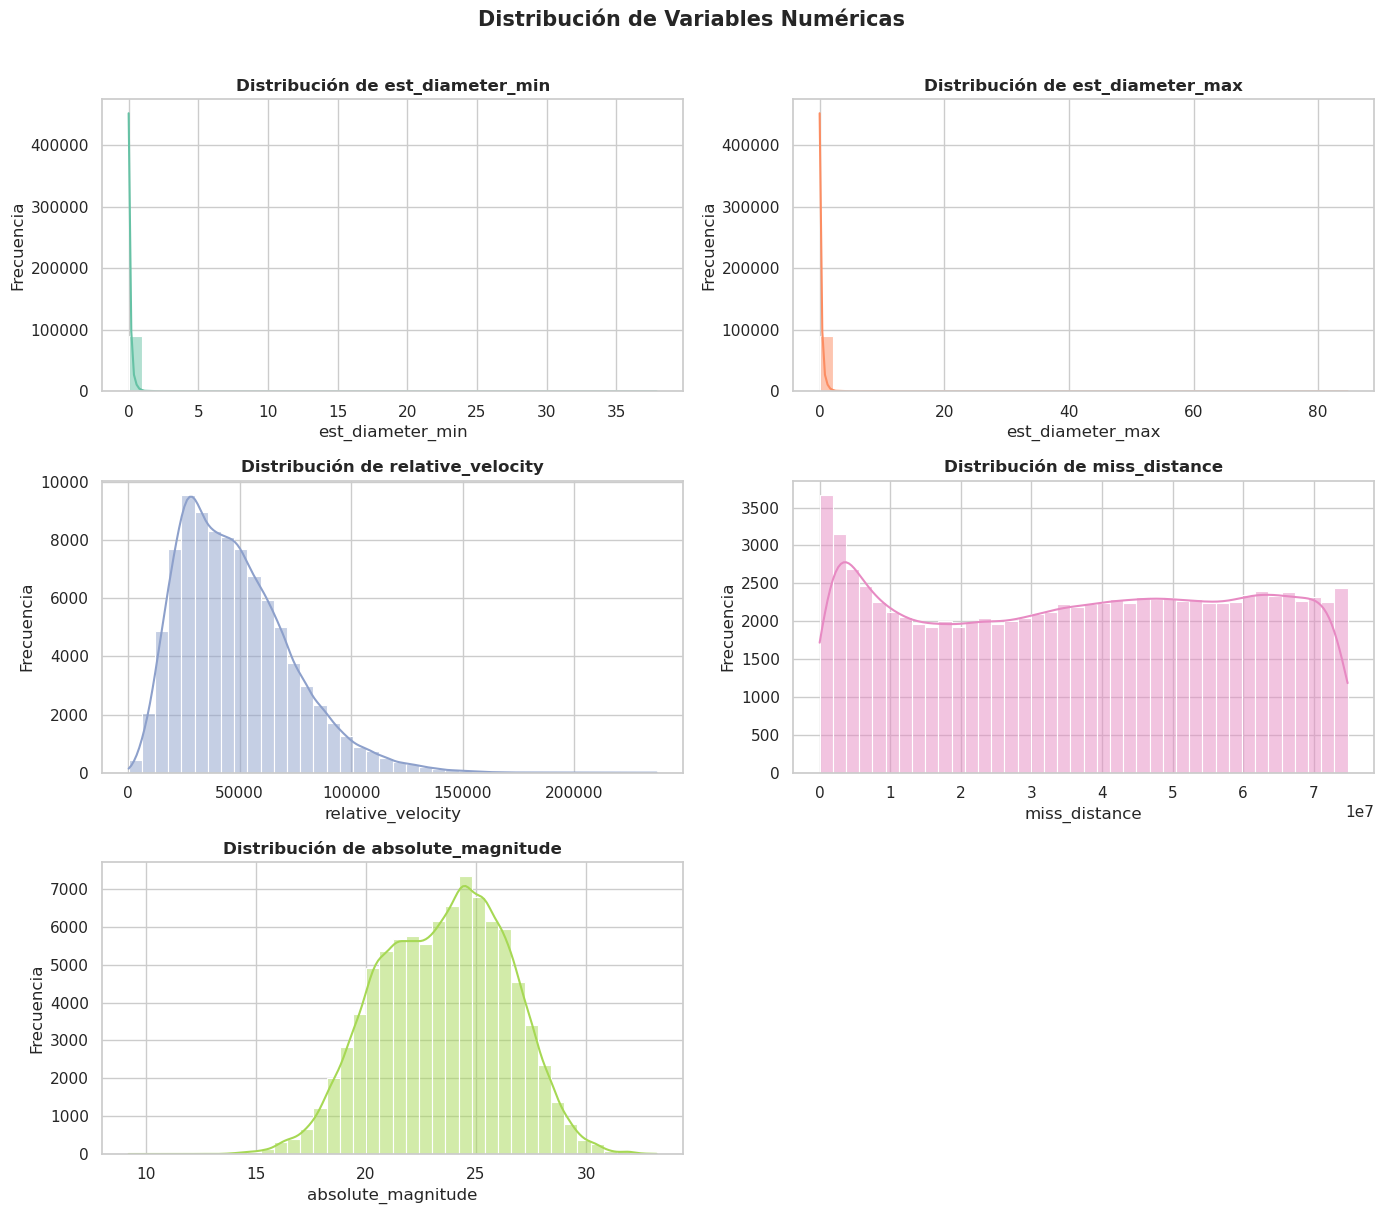

In [9]:
# Variables numéricas a graficar (excluyendo el id)
columnas_plot = [
    col for col in df.select_dtypes(include="number").columns if col != "id"
]

# Paleta de colores (un color por variable)
paleta_hist = sns.color_palette("Set2", len(columnas_plot))

# Grilla dinámica: 2 columnas, filas según cantidad de variables
n_columnas = 2
n_filas = -(-len(columnas_plot) // n_columnas)

fig, ejes = plt.subplots(n_filas, n_columnas, figsize=(14, n_filas * 4))
ejes = ejes.flatten()

for i, (col, color) in enumerate(zip(columnas_plot, paleta_hist)):
    sns.histplot(data=df, x=col, kde=True, color=color, ax=ejes[i], bins=40)
    ejes[i].set_title(f"Distribución de {col}", fontsize=12, fontweight="bold")
    ejes[i].set_xlabel(col)
    ejes[i].set_ylabel("Frecuencia")

# Ocultar ejes sobrantes
for j in range(i + 1, len(ejes)):
    ejes[j].set_visible(False)

plt.suptitle(
    "Distribución de Variables Numéricas", fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

Las distribuciones revelan comportamientos muy distintos entre variables:

- `est_diameter_min` y `est_diameter_max` presentan una asimetría extrema hacia la derecha, es decir, la gran mayoría de los asteroides se concentran cerca de cero, con una cola que se extiende hasta 37 y 84 km respectivamente. Son las variables con mayor presencia de valores extremos y serán las más afectadas por la estandarización.

- `relative_velocity` muestra una distribución asimétrica con cola derecha, pero más suave que los diámetros. Los datos se concentran entre 0 y ~75.000 km/s con un peak alrededor de los 30.000, y una cola que se extiende hasta ~237.000.

- `miss_distance` es la más inusual, ya que su distribución es prácticamente plana a lo largo de todo el rango (de 0 a 75 millones de km), con un leve peak inicial. Esto sugiere que los asteroides registrados se distribuyen de forma bastante uniforme, es decir,no hay una distancia "típica".

- `absolute_magnitude` es la única variable con distribución aproximadamente normal, centrada alrededor de 24-25.

La asimetría de los diámetros y la velocidad relativa confirman que una transformación logarítmica podría ser útil, aunque esto se evaluará en la etapa de preparación de datos.

### 2.2 Correlación entre Variables

Se analiza la relación lineal entre variables numéricas mediante una matriz de correlación de Pearson. Esto permite identificar redundancias entre predictores y anticipar posibles problemas de multicolinealidad antes del modelado.

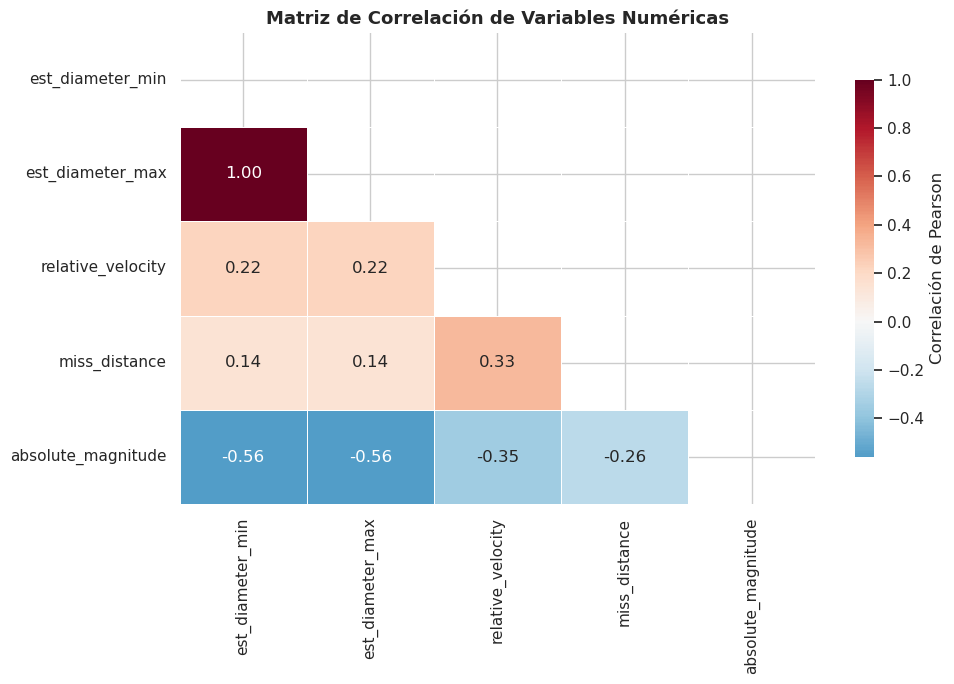

In [10]:
# Excluir id antes de calcular correlaciones
matriz_corr = df.drop(columns="id").select_dtypes(include="number").corr()

# Máscara para mostrar solo triángulo inferior (el superior es espejo exacto)
triangulo = np.triu(np.ones_like(matriz_corr, dtype=bool))

fig, eje = plt.subplots(figsize=(10, 7))

sns.heatmap(
    matriz_corr,
    mask=triangulo,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor="white",
    ax=eje,
    cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"},
)

eje.set_title(
    "Matriz de Correlación de Variables Numéricas", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

La matriz revela dos patrones claros:

- `est_diameter_min` y `est_diameter_max` tienen correlación de 1.00, recogen prácticamente la misma información pero de puntos distintos. En la etapa de preparación se eliminará una de las dos para evitar redundancia.

- `absolute_magnitude` correlaciona negativamente con todas las demás variables: -0.56 con los diámetros, -0.35 con `relative_velocity` y -0.26 con `miss_distance`. Es decir, asteroides más brillantes (magnitud baja) tienden a ser más grandes, más rápidos y a pasar más cerca. Lo que tiene sentido físicamente.

- El resto de las correlaciones son débiles (entre 0.14 y 0.33), lo que indica que las variables aportan información mayormente independiente entre sí.

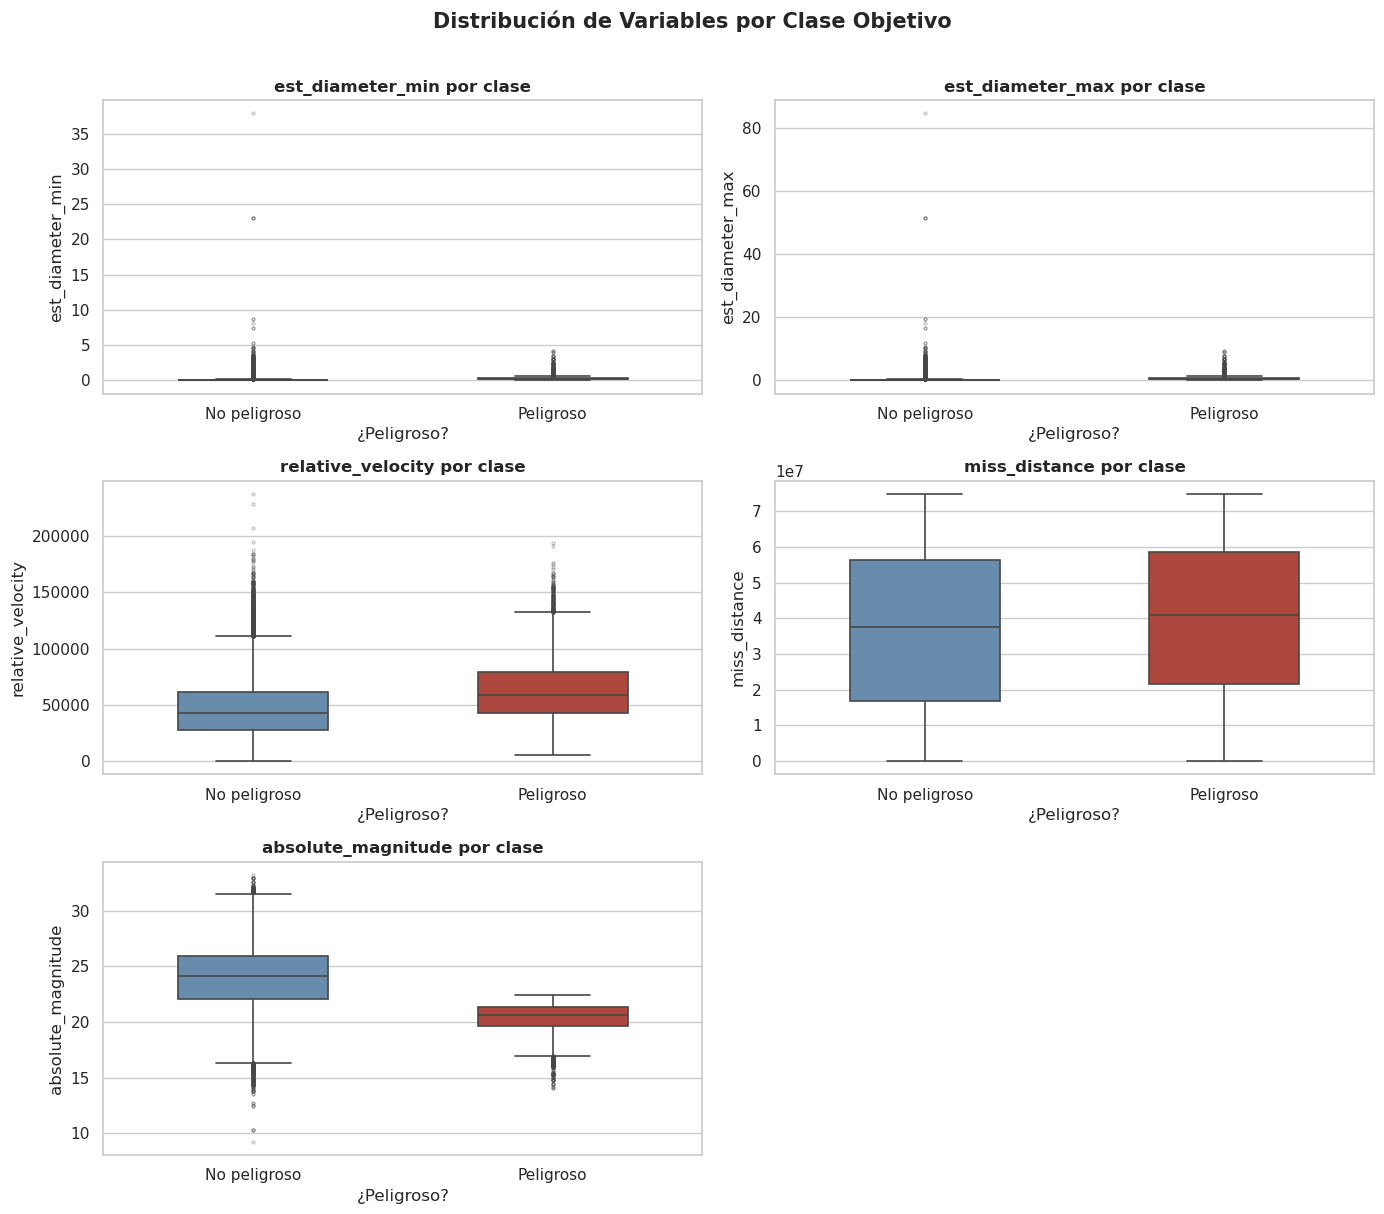

In [11]:
# Boxplots por clase objetivo
cols_box = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude",
]

# Grilla dinámica: 2 columnas, filas según cantidad de variables
n_columnas = 2
n_filas = -(-len(cols_box) // n_columnas)

fig, ejes = plt.subplots(n_filas, n_columnas, figsize=(14, n_filas * 4))
ejes = ejes.flatten()

colores_clase = {"False": "#5b8db8", "True": "#c0392b"}

# Boxplot para cada variable por clase objetivo
for i, col in enumerate(cols_box):
    sns.boxplot(
        data=df,
        x="hazardous",
        y=col,
        ax=ejes[i],
        palette=colores_clase,
        width=0.5,
        linewidth=1.2,
        flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
    )
    ejes[i].set_title(f"{col} por clase", fontsize=12, fontweight="bold")
    ejes[i].set_xlabel("¿Peligroso?")
    ejes[i].set_ylabel(col)
    ejes[i].set_xticklabels(["No peligroso", "Peligroso"])

for j in range(i + 1, len(ejes)):
    ejes[j].set_visible(False)

plt.suptitle(
    "Distribución de Variables por Clase Objetivo",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

Los boxplots revelan qué variables separan mejor las dos clases:

- `absolute_magnitude` es la variable con mayor separación visible, donde los asteroides peligrosos tienen valores notablemente más bajos (mediana ~21) que los no peligrosos (mediana ~24). Dado que menor magnitud implica mayor brillo y tamaño, esto indica que los asteroides peligrosos tienden a ser más grandes, lo que tiene sentido físicamente y sugiere que esta variable será relevante para el modelo.

- `relative_velocity` muestra una separación moderada. Los ateroides peligrosos tienen una mediana ligeramente superior y una distribución más concentrada, mientras que los no peligrosos presentan mayor dispersión y más outliers hacia velocidades extremas.

- `est_diameter_min` y `est_diameter_max` no muestran separación clara entre clases, ya que ambas distribuciones son casi idénticas y dominadas por outliers. Su correlación perfecta con la otra variable de diámetro refuerza la decisión de eliminar una de las dos.

- `miss_distance` no hay mucha distición entre clases, las cajas son casi del mismo tamaño y posición.
  
En síntesis, `absolute_magnitude` aparece como el predictor más prometedor, seguido de `relative_velocity`.

## 3. Preparación de Datos

Con el análisis exploratorio como base, se aplican las transformaciones necesarias antes del modelado.
Las decisiones tomadas aquí no son arbitrarias, ya que cada una responde a algo que se observó en las secciones anteriores.

### 3.1 Eliminación de Columnas

Se eliminan cuatro columnas identificadas durante la inspección inicial:

- `id` y `name`: identificadores sin valor predictivo.
- `orbiting_body` y `sentry_object`: columnas constantes sin variabilidad.
- Adicionalmente, se elimina `est_diameter_max` por su correlación perfecta (1.00) con `est_diameter_min`, ya que ambas miden lo mismo y mantener las dos introduciría redundancia innecesaria.

In [12]:
# Eliminación de columnas no relevantes para el modelado
columnas_elim = ["id", "name", "orbiting_body", "sentry_object", "est_diameter_max"]

df_clean = df.drop(columns=columnas_elim).copy()

print(f"Columnas originales: {df.shape[1]}")
print(f"Columnas tras limpieza: {df_clean.shape[1]}")
print(f"Columnas restantes: {list(df_clean.columns)}")

Columnas originales: 10
Columnas tras limpieza: 5
Columnas restantes: ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous']


### 3.2 Separación de features y variable objetivo

In [13]:
# Preparación de datos para modelado
cols_X = [col for col in df_clean.columns if col != "hazardous"]

X = df_clean[cols_X]
y = df_clean["hazardous"].astype(int)

print(f"Features ({len(cols_X)}): {cols_X}")
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

Features (4): ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
Shape X: (90836, 4)
Shape y: (90836,)


### 3.3 División en entrenamiento y prueba

Se usa `stratify=y` para garantizar que la proporción de asteroides peligrosos (9.7%) se mantenga tanto en el conjunto de entrenamiento como en el de prueba. Esto es relevante debido al desbalance de clases identificado anteriormente.

In [14]:
# Partición estratificada para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Prueba: {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.1f}%)\n")
print(f"Proporción hazardous en entrenamiento: {y_train.mean()*100:.1f}%")
print(f"Proporción hazardous en prueba: {y_test.mean()*100:.1f}%")

Entrenamiento: 72,668 filas (80.0%)
Prueba: 18,168 filas (20.0%)

Proporción hazardous en entrenamiento: 9.7%
Proporción hazardous en prueba: 9.7%


### 3.4 Escalado

El escalado se aplica dentro de los pipelines de cada modelo en la siguiente sección, no aquí de forma independiente. Esto evita *data leakage*, ya que si se escala antes del split, la información del conjunto de prueba contamina los parámetros del scaler.

`StandardScaler` dentro del pipeline aprende la media y desviación estándar exclusivamente del conjunto de entrenamiento y aplica esa misma transformación al de prueba.

### 3.5 Tratamiento de Outliers

El análisis exploratorio identificó valores extremos en distintas variables, por ejemplo, `est_diameter_min`, `est_diameter_max` y `relative_velocity`. Sin embargo, se decide no imputar ni eliminar estos outliers por
las siguientes razones:

- **Son valores reales**: un asteroide de 37 km de diámetro o con velocidad de 236.000 km/s existe y es parte del fenómeno que se modela. Eliminarlos sería perder información legítima sobre casos extremos que podrían ser precisamente los más peligrosos.

- **Random Forest es robusto a outliers**: los árboles de decisión operan con cortes en umbrales, no con distancias, por lo que los valores extremos no distorsionan el aprendizaje.

- **El escalado está en el pipeline**: `StandardScaler` normaliza la escala de cada variable, reduciendo el impacto relativo de los valores extremos sin eliminarlos.

### 3.6 Exportación del Dataset Limpio

In [16]:
df_clean.to_csv("../data/processed/neo_clean.csv", index=False)

print(f"Dataset limpio exportado: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas")
print("Ruta: data/processed/neo_clean.csv")

Dataset limpio exportado: 90,836 filas x 5 columnas
Ruta: data/processed/neo_clean.csv


## 4. Modelado Supervisado

Con los datos preparados, se implementan tres modelos de clasificación usando `Pipeline` de Scikit-learn, que encadena el escalado y el modelo en un objeto único, garantizando que el preprocesamiento se aplique correctamente en cada fold de validación cruzada.

Se eligieron tres algoritmos con lógicas distintas para comparar enfoques:

- **Regresión Logística**: modelo lineal, rápido e interpretable. Sirve como baseline.

- **Random Forest**: ensemble de árboles de decisión, robusto a outliers y no requiere que las variables sean linealmente separables.
  
- **Gradient Boosting**: ensamble secuencial que corrige errores iterativamente,generalmente más preciso que Random Forest pero más costoso en cómputo.

### 4.1 Definición de Pipelines

In [ ]:
# Definición de pipelines para modelos supervisados

# Pipeline Regresión Logística
pipeline_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(random_state=SEED, max_iter=1000)),
    ]
)

# Pipeline Random Forest
pipeline_rf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    ]
)

# Pipeline Gradient Boosting
pipeline_gb = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", GradientBoostingClassifier(random_state=SEED)),
    ]
)

pipelines = {
    "Regresión Logística": pipeline_lr,
    "Random Forest": pipeline_rf,
    "Gradient Boosting": pipeline_gb,
}

print("Pipelines definidos:")
for nombre, pipeline in pipelines.items():
    print(f"- {nombre}: {[paso[0] for paso in pipeline.steps]}")

Pipelines definidos:
- Regresión Logística: ['scaler', 'classifier']
- Random Forest: ['scaler', 'classifier']
- Gradient Boosting: ['scaler', 'classifier']


### 4.2 Entrenamiento

Se entrena cada pipeline sobre el conjunto de entrenamiento. 

En esta etapa no se evalúa el rendimiento, debido a que eso se hace formalmente en la siguiente sección con validación cruzada.

In [32]:
# Entrenamiento de modelos
for nombre, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"- {nombre} entrenado")

- Regresión Logística entrenado
- Random Forest entrenado
- Gradient Boosting entrenado


### 4.3 Evaluación preliminar sobre conjunto de prueba

Como primera aproximación, se obtiene el reporte de clasificación de cada modelo
sobre el conjunto de prueba. Esto da una visión inicial antes de la evaluación
formal con validación cruzada.

In [ ]:
# Evaluación inicial con reporte de clasificación
for nombre, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    print(f"{'─'*50}")
    print(f" {nombre}")
    print(f"{'─'*50}")
    print(
        classification_report(
            y_test, y_pred, target_names=["No peligroso", "Peligroso"]
        )
    )

──────────────────────────────────────────────────
 Regresión Logística
──────────────────────────────────────────────────
              precision    recall  f1-score   support

No peligroso       0.91      0.99      0.95     16400
   Peligroso       0.52      0.08      0.13      1768

    accuracy                           0.90     18168
   macro avg       0.71      0.53      0.54     18168
weighted avg       0.87      0.90      0.87     18168

──────────────────────────────────────────────────
 Random Forest
──────────────────────────────────────────────────
              precision    recall  f1-score   support

No peligroso       0.94      0.97      0.95     16400
   Peligroso       0.59      0.39      0.47      1768

    accuracy                           0.91     18168
   macro avg       0.77      0.68      0.71     18168
weighted avg       0.90      0.91      0.91     18168

──────────────────────────────────────────────────
 Gradient Boosting
────────────────────────────────────

Los tres modelos alcanzan accuracy similar (~90-91%), lo que confirma lo anticipado: esta métrica no discrimina entre modelos cuando hay desbalance de clases.

El análisis se enfoca en el rendimiento sobre la clase Peligroso:

- **Regresión Logística** es el modelo más débil sobre la clase minoritaria con recall de **0.08** y F1 de **0.13**. En la práctica, detecta apenas 1 de cada 12 asteroides peligrosos. Esto es un problema, al ser un área donde los falsos negativos tienen consecuencias críticas.

- **Random Forest** mejora considerablemente con un recall de **0.39** y F1 de **0.47**. Detecta más asteroides peligrosos que la regresión logística, aunque todavía deja pasar el 61% de la clase positiva.

- **Gradient Boosting** presenta el comportamiento más llamativo con una precision muy alta (**0.84**) pero con un recall de apenas **0.15**. Cuando predice "peligroso" (casi siempre) acierta, pero deja pasar la mayoría de los casos reales.

Ningún modelo es satisfactorio aún en su configuración por defecto. El **Random Forest** ofrece el mejor balance entre precision y recall (F1 = 0.47), pero hay margen de mejora considerable.

La optimización de hiperparámetros en la Sección 6 buscará mejorar específicamente el recall sobre la clase peligrosa.

## 5. Evaluación con validación cruzada

La evaluación preliminar de la sección anterior usa una sola partición de datos, lo que introduce variabilidad según cómo quedó ese split particular. La validación cruzada estratificada resuelve esto dividiendo el conjunto de entrenamiento en `k` folds, entrenando en `k-1` y evaluando en el restante, rotando hasta que todos los folds hayan sido usados como conjunto de evaluación. 

El resultado es una estimación más robusta y menos dependiente del azar.

A continuación, se usan **5 folds estratificados** para mantener la proporción de clases en cada partición, y se calculan cuatro métricas por modelo: F1, ROC-AUC, precision y recall, todas sobre la clase positiva (`Peligroso`).

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

metricas = ["f1", "roc_auc", "precision", "recall"]

resultados_cv = {}

for nombre, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=metricas, n_jobs=-1
    )
    resultados_cv[nombre] = {metrica: scores[f"test_{metrica}"] for metrica in metricas}
    print(f"- {nombre} evaluado")

- Regresión Logística evaluado
- Random Forest evaluado
- Gradient Boosting evaluado


### 5.1 Resultados por métrica

In [ ]:
# Tabla resumen de resultados de validación cruzada
filas = []
for nombre, scores in resultados_cv.items():
    fila = {"Modelo": nombre}
    for metrica, valores in scores.items():
        fila[f"{metrica} (media)"] = valores.mean().round(4)
        fila[f"{metrica} (std)"] = valores.std().round(4)
    filas.append(fila)

tabla_cv = pd.DataFrame(filas).set_index("Modelo")
display(tabla_cv)

,f1 (media),f1 (std),roc_auc (media),roc_auc (std),precision (media),precision (std),recall (media),recall (std)
Modelo,,,,,,,,
Regresión Logística,0.1191,0.0120,0.8773,0.0027,0.4744,0.0193,0.0682,0.0076
Random Forest,0.4613,0.0098,0.9292,0.0018,0.6116,0.0113,0.3703,0.0088
Gradient Boosting,0.2387,0.0107,0.9183,0.0022,0.7789,0.0045,0.1410,0.0074


Los tres modelos alcanzan ROC-AUC alto (0.877 a 0.929), lo que indica que todos tienen capacidad discriminativa real. Sin embargo, las métricas sobre la clase **Peligroso** cuentan una historia distinta:

- **Regresión Logística**: F1 de 0.119 y recall de 0.068 detecta menos de 1 de cada 10 asteroides peligrosos. Su ROC-AUC de 0.877 sugiere que el modelo sabe distinguir entre clases, pero el umbral por defecto (0.5) no es adecuado para este desbalance.

- **Random Forest**: el más equilibrado con F1 de 0.461 y recall de 0.370. Su ROC-AUC de 0.929 es el más alto de los tres, lo que lo posiciona como el mejor candidato para optimización.

- **Gradient Boosting**: precision alta (0.779) pero recall muy bajo (0.141), es extremadamente selectivo al predecir "peligroso". Su F1 de 0.239 refleja ese desequilibrio.

Las desviaciones estándar bajas en todos los modelos confirman que los resultados son estables entre folds y no dependen del split particular.

### 5.2 Comparación visual entre modelos

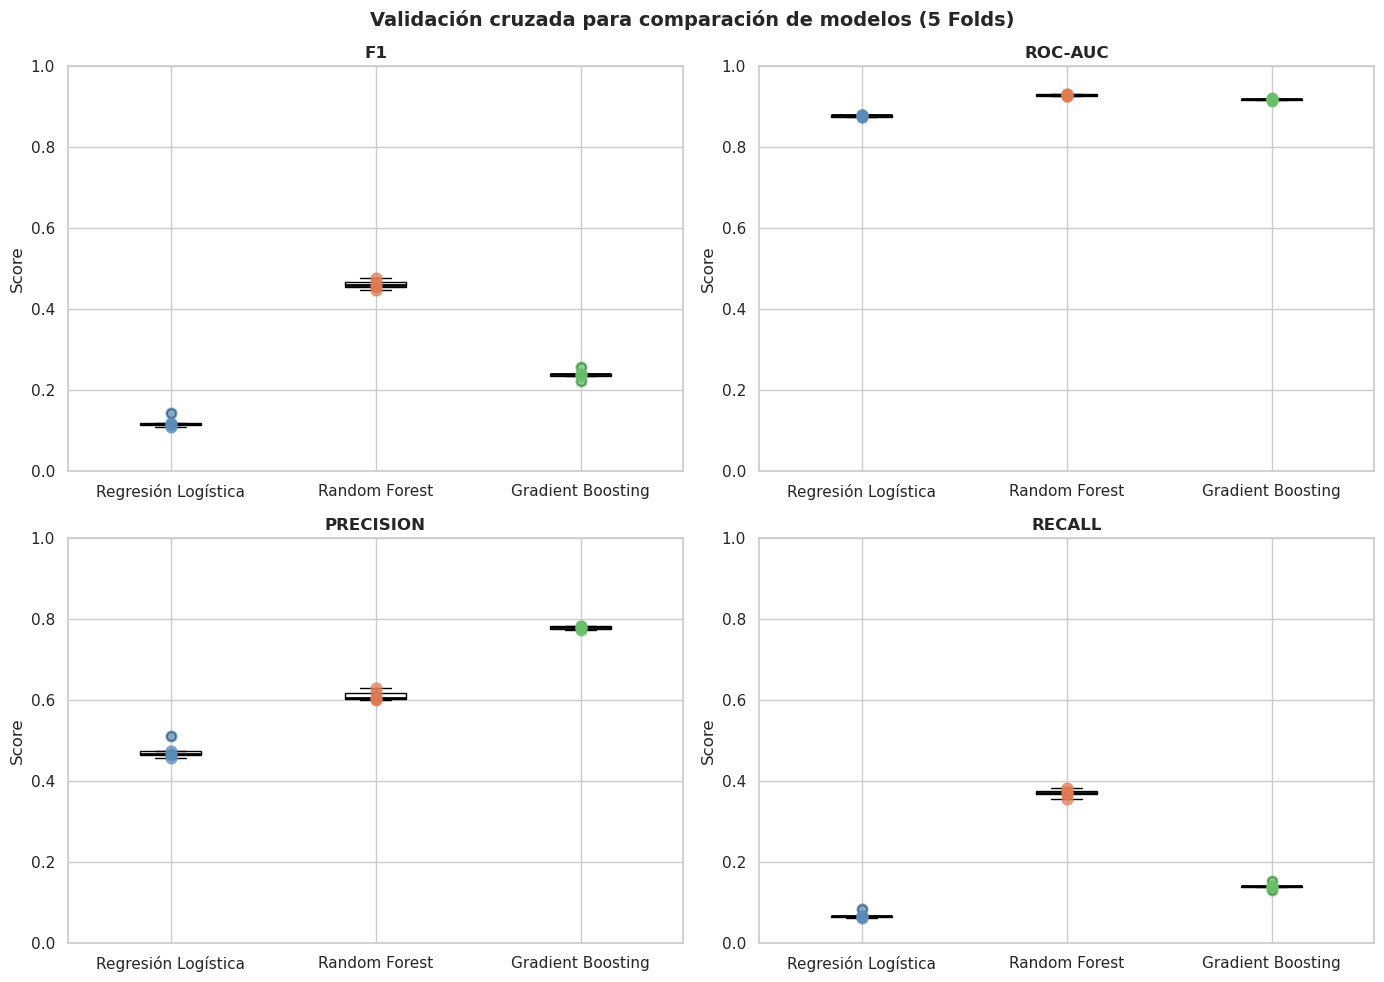

In [ ]:
# Visualización de resultados de validación cruzada

# Grilla 2x2 para las 4 métricas
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))
ejes = ejes.flatten()

colores_modelos = ["#5b8db8", "#e07b54", "#6abf69"]

# Boxplot + scatter para cada métrica

for i, metrica in enumerate(metricas):
    datos_metrica = [resultados_cv[nombre][metrica] for nombre in pipelines.keys()]
    ejes[i].boxplot(
        datos_metrica,
        labels=list(pipelines.keys()),
        patch_artist=True,
        boxprops=dict(facecolor="none"),
        medianprops=dict(color="black", linewidth=2),
    )
    for j, (datos, color) in enumerate(zip(datos_metrica, colores_modelos)):
        ejes[i].scatter(
            [j + 1] * len(datos), datos, color=color, alpha=0.7, zorder=3, s=60
        )
    ejes[i].set_title(metrica.upper().replace("_", "-"), fontsize=12, fontweight="bold")
    ejes[i].set_ylabel("Score")
    ejes[i].set_ylim(0, 1)

plt.suptitle(
    "Validación cruzada para comparación de modelos (5 Folds)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

La validación cruzada confirma y matiza lo observado en la evaluación preliminar. Con 5 folds, los resultados son estables (desviaciones estándar bajas en todos los modelos) lo que indica que el rendimiento no depende del split particular.

Mirando las métricas sobre la clase **Peligroso**:

- **Regresión Logística** queda descartada como candidato principal: F1 de **0.12** y recall de **0.07** son consistentemente bajos en todos los folds. Su ROC-AUC de 0.88 revela que el modelo tiene capacidad discriminativa, pero el umbral por defecto (0.5) no es adecuado para este desbalance. Es decir, un problema de calibración más que de aprendizaje.

- **Random Forest** es el modelo más equilibrado, con F1 de **0.46**, recall de **0.37** y ROC-AUC de **0.93** (el más alto de los tres). Detecta más asteroides peligrosos que los otros dos modelos sin sacrificar demasiado la precision (0.61).

- **Gradient Boosting** presenta el trade-off más extremo con precision de **0.78** pero recall de apenas **0.14**. Es el modelo más conservador, muy selectivo al predecir "peligroso", pero deja pasar la mayoría de los casos reales.

El **Random Forest** emerge como el mejor modelo en configuración base. La optimización de hiperparámetros en la siguiente sección buscará mejorar el recall sin colapsar la precision, tanto para Random Forest como para Gradient Boosting.

## 6. Optimización de Hiperparámetros

Los modelos entrenados hasta ahora usan configuraciones por defecto. La optimización de hiperparámetros busca encontrar la combinación de parámetros que maximice el rendimiento sobre la clase minoritaria, en este caso, maximizando **F1** sobre la clase `Peligroso`.

Se aplican dos estrategias complementarias:

- **GridSearchCV** sobre Regresión Logística: búsqueda exhaustiva sobre un espacio acotado.
- **RandomizedSearchCV** sobre Random Forest: búsqueda aleatoria sobre un espacio más amplio, más eficiente cuando hay muchos hiperparámetros posibles.

Ambas búsquedas usan validación cruzada estratificada de 5 folds internamente.

### 6.1 GridSearchCV — Regresión Logística

In [ ]:
# Optimización de hiperparámetros para Regresión Logística
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"],
}

# Configuración de GridSearchCV
grid_lr = GridSearchCV(
    pipeline_lr, param_grid=param_grid_lr, cv=cv, scoring="f1", n_jobs=-1, verbose=0
)

grid_lr.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_lr.best_params_}")
print(f"Mejor F1 (CV): {grid_lr.best_score_:.4f}")

Mejores parámetros: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Mejor F1 (CV): 0.1196


La búsqueda exhaustiva encuentra como configuración óptima `C=10` con regularización `l2`. Un valor alto de `C` implica menos regularización, por lo que el modelo se ajusta más a los datos de entrenamiento, lo que en este caso ayuda marginalmente a capturar la clase minoritaria.

Sin embargo, el mejor F1 de 0.1196 es prácticamente idéntico al modelo base (0.1191). La Regresión Logística tiene un techo claro en este problema, ya que la relación entre las features y `hazardous` no es suficientemente lineal como para que el ajuste de hiperparámetros produzca mejoras relevantes. 

Esto refuerza la decisión de enfocarse en el Random Forest como modelo principal.

### 6.2 RandomizedSearchCV — Random Forest

In [ ]:
# Optimización de hiperparámetros para Random Forest
param_dist_rf = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": ["balanced", None],
}

# Configuración de RandomizedSearchCV
random_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=cv,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)

random_rf.fit(X_train, y_train)

print(f"Mejores parámetros: {random_rf.best_params_}")

print(f"Mejor F1 (CV): {random_rf.best_score_:.4f}")

Mejores parámetros: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': None, 'classifier__class_weight': 'balanced'}
Mejor F1 (CV): 0.5375


La búsqueda aleatoria encuentra una mejora concreta respecto al modelo base. Los parámetros óptimos revelan decisiones interesantes:

- `class_weight: balanced` es el parámetro más relevante, ya que le indica al modelo que pondere inversamente la frecuencia de cada clase, compensando el desbalance 90/10 de forma automática. Es probablemente el cambio que más impacta el F1.

- `max_depth: None` permite que los árboles crezcan sin restricción, capturando patrones más complejos en los datos.

- `min_samples_split: 10` y `min_samples_leaf: 4` introducen regularización implícita, evitan divisiones sobre grupos muy pequeños, reduciendo el riesgo de sobreajuste.

El F1 sube de 0.4613 a 0.5375, una mejora de casi 8 puntos porcentuales sobre la clase peligrosa. No es un salto drástico, pero es consistente y reproducible a través de los 5 folds.

### 6.3 Evaluación de modelos optimizados

In [ ]:
# Evaluación de modelos optimizados en el conjunto de prueba
modelos_optimizados = {
    "Regresión Logística (optimizada)": grid_lr.best_estimator_,
    "Random Forest (optimizado)": random_rf.best_estimator_,
}

# Evaluación final con reporte de clasificación
for nombre, modelo in modelos_optimizados.items():
    y_pred = modelo.predict(X_test)
    print(f"{'─'*55}")
    print(f" {nombre}")
    print(f"{'─'*55}")
    print(
        classification_report(
            y_test, y_pred, target_names=["No peligroso", "Peligroso"]
        )
    )

───────────────────────────────────────────────────────
 Regresión Logística (optimizada)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

No peligroso       0.91      0.99      0.95     16400
   Peligroso       0.52      0.08      0.13      1768

    accuracy                           0.90     18168
   macro avg       0.71      0.53      0.54     18168
weighted avg       0.87      0.90      0.87     18168

───────────────────────────────────────────────────────
 Random Forest (optimizado)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

No peligroso       0.97      0.90      0.93     16400
   Peligroso       0.44      0.72      0.54      1768

    accuracy                           0.88     18168
   macro avg       0.70      0.81      0.74     18168
weighted avg       0.92      0.88      0.89     18168



Los reportes sobre el conjunto de prueba confirman el impacto real de la optimización:

- **Regresión Logística optimizada**: sin cambios respecto al modelo base, precision 0.52, recall 0.08, F1 0.13. Exactamente lo esperado dado que la búsqueda de hiperparámetros no logró mejora significativa en validación cruzada.

- **Random Forest optimizado**: el cambio es sustancial. El recall sube de 0.39 a 0.72. El modelo ahora detecta 7 de cada 10 asteroides peligrosos, frente a menos de 4 de cada 10 en su configuración base. El costo es una caída en precision de 0.59 a 0.44, lo que significa más falsos positivos.

- El F1 del Random Forest optimizado (0.54) supera a todos los modelos base y confirma que `class_weight: balanced` fue el ajuste más determinante de la optimización.

### 6.4 Comparación antes y después de la optimización

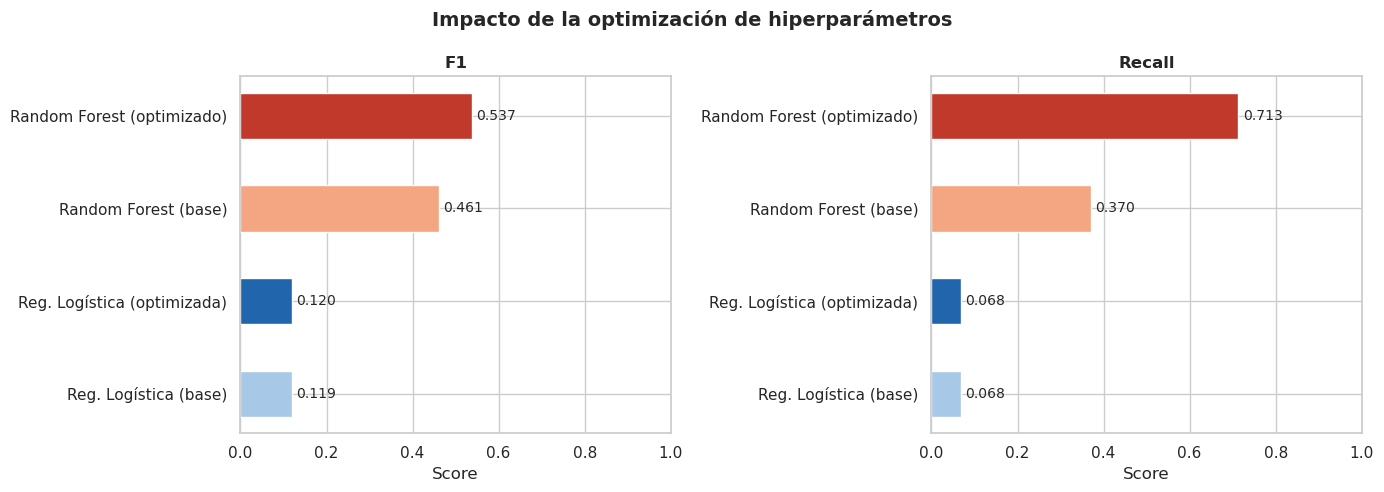

In [ ]:
# Comparación de métricas antes y después de la optimización
f1_lr_opt = cross_val_score(
    grid_lr.best_estimator_, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
).mean()
recall_lr_opt = cross_val_score(
    grid_lr.best_estimator_, X_train, y_train, cv=cv, scoring="recall", n_jobs=-1
).mean()
f1_rf_opt = cross_val_score(
    random_rf.best_estimator_, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
).mean()
recall_rf_opt = cross_val_score(
    random_rf.best_estimator_, X_train, y_train, cv=cv, scoring="recall", n_jobs=-1
).mean()

comparacion = {
    "Modelo": [
        "Reg. Logística (base)",
        "Reg. Logística (optimizada)",
        "Random Forest (base)",
        "Random Forest (optimizado)",
    ],
    "F1": [
        resultados_cv["Regresión Logística"]["f1"].mean(),
        f1_lr_opt,
        resultados_cv["Random Forest"]["f1"].mean(),
        f1_rf_opt,
    ],
    "Recall": [
        resultados_cv["Regresión Logística"]["recall"].mean(),
        recall_lr_opt,
        resultados_cv["Random Forest"]["recall"].mean(),
        recall_rf_opt,
    ],
}

df_comparacion = pd.DataFrame(comparacion).set_index("Modelo")

# Visualización comparativa de métricas antes y después de la optimización
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

for i, metrica in enumerate(["F1", "Recall"]):
    colores = ["#a8c8e8", "#2166ac", "#f4a582", "#c0392b"]
    barras = ejes[i].barh(
        df_comparacion.index,
        df_comparacion[metrica],
        color=colores,
        edgecolor="white",
        height=0.5,
    )
    for barra in barras:
        ancho = barra.get_width()
        ejes[i].text(
            ancho + 0.01,
            barra.get_y() + barra.get_height() / 2,
            f"{ancho:.3f}",
            va="center",
            fontsize=10,
        )
    ejes[i].set_title(metrica, fontsize=12, fontweight="bold")
    ejes[i].set_xlim(0, 1)
    ejes[i].set_xlabel("Score")

plt.suptitle(
    "Impacto de la optimización de hiperparámetros", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

El gráfico resume visualmente el impacto de la optimización en ambas métricas clave:

- **Regresión Logística** no muestra mejora visible en ninguna métrica, las barras base y optimizada son prácticamente indistinguibles (F1: 0.119 → 0.120, Recall: 0.068 → 0.068). La optimización no aporta nada a este modelo.

- **Random Forest** muestra una mejora clara y consistente, el F1 sube de 0.461 a 0.537  y el recall de 0.370 a 0.713, casi el doble. El gráfico hace evidente que la ganancia en recall es el cambio más significativo de todo el proceso de optimización.

El **Random Forest optimizado** es el modelo final del proyecto. Su recall de 0.713 significa que detecta correctamente casi 3 de cada 4 asteroides peligrosos, con un F1 que refleja un balance razonable entre precision y recall dado el desbalance del dataset.

## 7. Aprendizaje No Supervisado

Hasta ahora el análisis ha sido supervisado, los modelos aprendieron usando la etiqueta `hazardous`. Esta sección explora los datos sin esa información: ¿los asteroides forman grupos naturales? ¿esos grupos coinciden con la clasificación de peligrosidad?

Se aplican dos técnicas complementarias:
- **PCA** (Análisis de Componentes Principales): reduce las 4 dimensiones a 2 para poder visualizar la estructura del dataset.
- **KMeans**: agrupa los asteroides en clusters y se evalúa qué tan bien se alinean con la etiqueta real.

### 7.1 Reducción de dimensionalidad con PCA

Antes de clustering, se aplica PCA para entender cuánta varianza explica cada componente y para visualizar la separación entre clases en dos dimensiones.

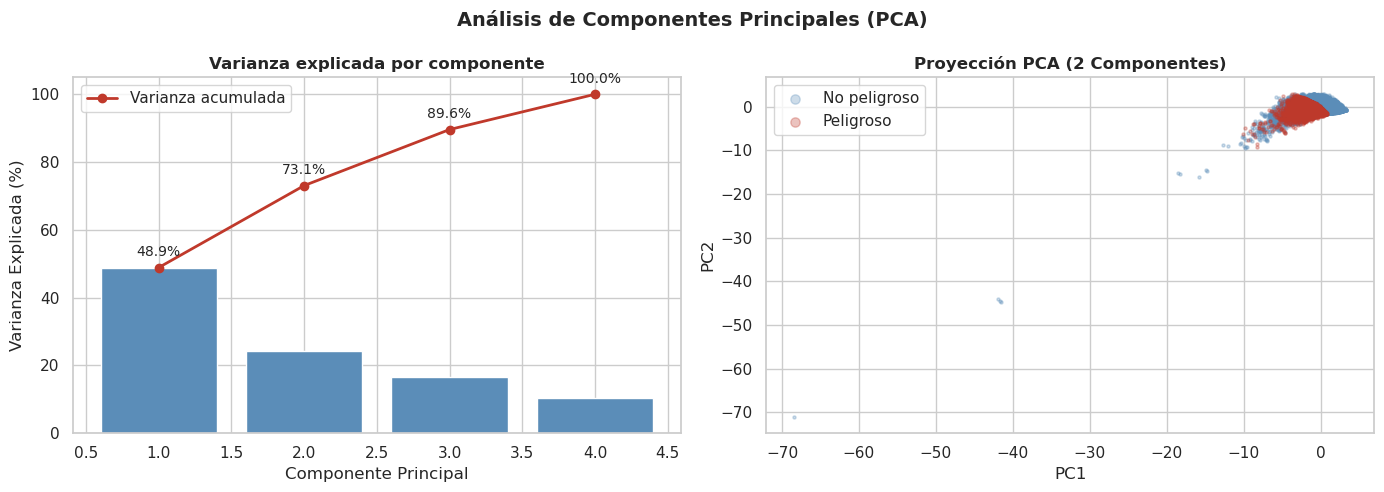

In [ ]:
# Análisis de Componentes Principales (PCA)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA(random_state=SEED)
pca.fit(X_scaled)

var_acumulada = np.cumsum(pca.explained_variance_ratio_)

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por componente
ejes[0].bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_ * 100,
    color="#5b8db8",
    edgecolor="white",
)
ejes[0].plot(
    range(1, len(var_acumulada) + 1),
    var_acumulada * 100,
    color="#c0392b",
    marker="o",
    linewidth=2,
    label="Varianza acumulada",
)
for i, v in enumerate(var_acumulada * 100):
    ejes[0].annotate(
        f"{v:.1f}%",
        (i + 1, v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=10,
    )

ejes[0].set_title("Varianza explicada por componente", fontweight="bold")
ejes[0].set_xlabel("Componente Principal")
ejes[0].set_ylabel("Varianza Explicada (%)")
ejes[0].legend()

# Proyección PCA con colores por clase
X_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)

colores_clase = {0: "#5b8db8", 1: "#c0392b"}
etiquetas_clase = {0: "No peligroso", 1: "Peligroso"}

for clase, color in colores_clase.items():
    mask = y == clase
    ejes[1].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=color,
        label=etiquetas_clase[clase],
        alpha=0.3,
        s=5,
    )

ejes[1].set_title("Proyección PCA (2 Componentes)", fontweight="bold")
ejes[1].set_xlabel("PC1")
ejes[1].set_ylabel("PC2")
ejes[1].legend(markerscale=3)

plt.suptitle(
    "Análisis de Componentes Principales (PCA)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

El análisis de componentes principales revela dos cosas:

- **Varianza explicada**: el primera componente (PC1) captura el **48.9%** de la varianza total, y las dos primeras juntas acumulan **73.1%**. Esto significa que una proyección 2D retiene casi tres cuartos de la información del dataset, suficiente para visualizar su estructura general sin perder demasiado.

- **Proyección 2D**: la separación entre clases es parcial pero no limpia. La mayoría de los puntos tanto peligrosos como no peligrosos se concentran en una región densa cerca del origen. 
  
  Los asteroides peligrosos (rojo) se superponen considerablemente con los no peligrosos (azul), lo que explica la dificultad de los modelos para separar ambas clases perfectamente. Los puntos dispersos hacia la izquierda y hacia abajo corresponden a outliers extremos identificados en el EDA, todos no peligrosos.

### 7.2 Clustering con KMeans

Se aplica KMeans con `k=2` como punto de partida natural dado que la variable objetivo tiene dos clases. Se usa el método del codo y el coeficiente de silueta para evaluar si `k=2` es efectivamente la partición más coherente.

k=2
k=3
k=4
k=5
k=6
k=7
k=8


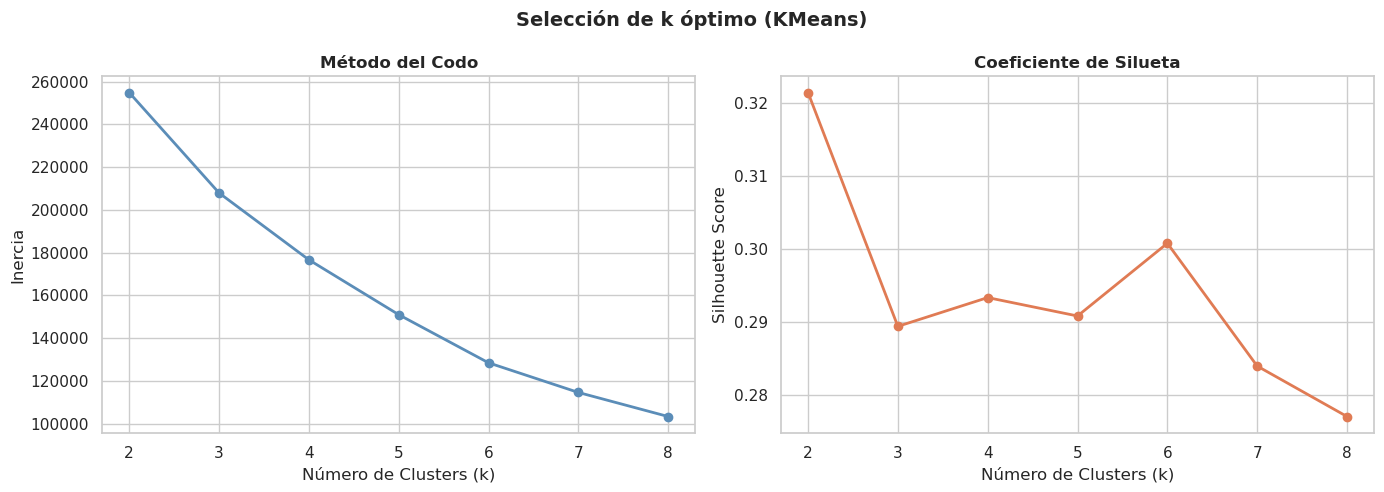

In [ ]:
from sklearn.metrics import silhouette_score

# Selección de k óptimo para KMeans usando método del codo e índice de silueta
rango_k = range(2, 9)
inercias = []
siluetas = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    siluetas.append(
        silhouette_score(X_scaled, labels, sample_size=10000, random_state=SEED)
    )
    print(f"k={k}")

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
ejes[0].plot(rango_k, inercias, marker="o", color="#5b8db8", linewidth=2)
ejes[0].set_title("Método del Codo", fontweight="bold")
ejes[0].set_xlabel("Número de Clusters (k)")
ejes[0].set_ylabel("Inercia")

# Coeficiente de silueta
ejes[1].plot(rango_k, siluetas, marker="o", color="#e07b54", linewidth=2)
ejes[1].set_title("Coeficiente de Silueta", fontweight="bold")
ejes[1].set_xlabel("Número de Clusters (k)")
ejes[1].set_ylabel("Silhouette Score")

plt.suptitle("Selección de k óptimo (KMeans)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

- **Método del codo**: la inercia decrece de forma continua sin un quiebre brusco evidente. La curva se aplana levemente alrededor de `k=5`, pero no hay un codo claro que indique un k óptimo natural, señal de que los datos no forman grupos muy compactos y separados.

- **Coeficiente de silueta**: el valor más alto es en `k=2` (0.32), lo que confirma que la partición en dos grupos es la más coherente de las evaluadas. A partir de `k=3` el score cae y se mantiene bajo, con una recuperación menor en `k=6`. Ambas métricas apuntan a `k=2` como la elección más justificable.

,No peligroso,Peligroso,Total
Cluster 0,51936,1475,53411
Cluster 1,30060,7365,37425
Total,81996,8840,90836


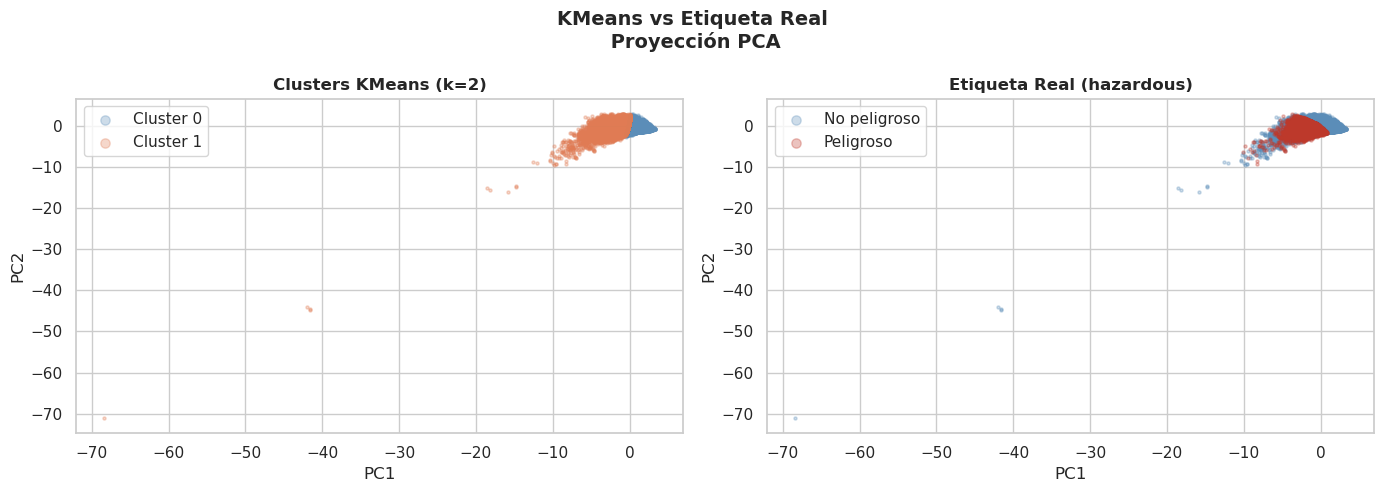

In [ ]:
km_final = KMeans(n_clusters=2, random_state=SEED, n_init=10)
clusters = km_final.fit_predict(X_scaled)

# Comparación cluster vs etiqueta real
comparacion_clusters = pd.crosstab(
    pd.Series(clusters, name="Cluster"),
    pd.Series(y.values, name="Hazardous real"),
    margins=True,
)
comparacion_clusters.columns = ["No peligroso", "Peligroso", "Total"]
comparacion_clusters.index = ["Cluster 0", "Cluster 1", "Total"]

display(comparacion_clusters)

# Proyección PCA coloreada por cluster
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

colores_cluster = {0: "#5b8db8", 1: "#e07b54"}

for cluster, color in colores_cluster.items():
    mask = clusters == cluster
    ejes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=color,
        label=f"Cluster {cluster}",
        alpha=0.3,
        s=5,
    )
ejes[0].set_title("Clusters KMeans (k=2)", fontweight="bold")
ejes[0].set_xlabel("PC1")
ejes[0].set_ylabel("PC2")
ejes[0].legend(markerscale=3)

for clase, color in colores_clase.items():
    mask = y == clase
    ejes[1].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=color,
        label=etiquetas_clase[clase],
        alpha=0.3,
        s=5,
    )
ejes[1].set_title("Etiqueta Real (hazardous)", fontweight="bold")
ejes[1].set_xlabel("PC1")
ejes[1].set_ylabel("PC2")
ejes[1].legend(markerscale=3)

plt.suptitle("KMeans vs Etiqueta Real\n Proyección PCA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

La tabla de comparación muestra que KMeans con `k=2` **no recupera la estructura de peligrosidad** de forma limpia:

- **Cluster 0** agrupa 53.411 asteroides, de los cuales solo 1.475 son peligrosos (2.8%).
- **Cluster 1** agrupa 37.425 asteroides, con 7.365 que son peligrosos (19.7%).

El Cluster 1 concentra el 83.3% de todos los asteroides peligrosos, lo que indica que KMeans sí captura una señal parcial, ya que los peligrosos tienden a agruparse juntos. Sin embargo, la superposición es considerable, debido a que el Cluster 1 también contiene 30.060 asteroides no peligrosos.

El gráfico de proyección PCA lo confirma visualmente: los clusters de KMeans no coinciden con la separación real por clase. La partición no supervisada captura diferencias en la estructura general del dataset, pero no la dimensión de peligrosidad específicamente.

Esto es consistente con lo observado en el EDA: las variables disponibles no generan una separación limpia entre clases en el espacio de features.

## 8. Conclusiones

Este proyecto recorrió un ciclo desde entender los datos hasta optimizar y comparar modelos. Las conclusiones que siguen no son un resumen de lo que ya está escrito, sino un cierre del razonamiento que fue construyendo cada sección.

### 8.1 Problema

El dataset NEO plantea un desafío que no es técnico en primer lugar: es conceptual. Con un 90.3% de asteroides no peligrosos, cualquier modelo que prediga siempre "no peligroso" alcanza ~90% de accuracy sin aprender nada. Esto significa que la métrica equivocada lleva a conclusiones completamente erróneas sobre el rendimiento.

El EDA reveló que `absolute_magnitude` es el predictor más informativo, con una separación clara entre clases (mediana 20.6 para peligrosos vs 24.1 para no peligrosos). El resto de las variables aportan señal más débil, y `miss_distance` prácticamente no distingue entre clases. La baja separabilidad en el espacio de features, confirmada por la proyección PCA, explica por qué ningún modelo alcanza resultados perfectos.

### 8.2 Modelos

Los tres modelos supervisados cuentan historias distintas sobre el mismo problema:

- **Regresión Logística** demostró que la relación entre las features y `hazardous` no es lineal. Su recall de 0.07 no es un fallo de calibración de hiperparámetros, es un límite del supuesto del modelo. La búsqueda exhaustiva con `GridSearchCV` lo confirmó, ya que el mejor F1 apenas movió de 0.119 a 0.120.

- **Random Forest** fue el modelo más equilibrado en todas las etapas. Su ROC-AUC de 0.929 en validación cruzada indica capacidad discriminativa real. Con la optimización (`class_weight: balanced`, `min_samples_leaf: 4`), el recall subió de 0.37 a 0.71, es decir, detecta correctamente 7 de cada 10 asteroides peligrosos, con un costo aceptable en precision.

- **Gradient Boosting** mostró el trade-off más extremo, precision alta (0.78) y recall muy bajo (0.14). Es el modelo más conservador, útil si el costo de los falsos positivos fuera muy alto, pero inadecuado para un problema donde los falsos negativos, asteroides peligrosos no detectados, tienen consecuencias más graves.

El **Random Forest optimizado** es la elección final. No es el modelo perfecto, sino el modelo más razonable dado el desbalance del dataset y la señal disponible en las features.

### 8.3 Proceso

Dos decisiones técnicas marcaron la diferencia más que cualquier otra:

- **Stratify en el split y en la validación cruzada**: sin `stratify=y`, el desbalance 90/10 podría generar folds con proporciones muy distintas de la clase positiva, produciendo estimaciones de rendimiento inestables. `StratifiedKFold` garantizó que cada fold evaluara el mismo problema.

- `class_weight: balanced`: un solo parámetro que casi duplicó el recall del Random Forest (de 0.37 a 0.71). La razón es directa, sin este ajuste, el modelo aprende implícitamente que equivocarse sobre la clase mayoritaria es "más barato". Al balancear los pesos, se le indica que un falso negativo sobre un asteroide peligroso tiene el mismo costo que un falso positivo sobre uno inofensivo.

- La integración del escalado dentro de los `Pipeline` evitó data leakage de forma sistemática, el `StandardScaler` aprendió parámetros solo del conjunto de entrenamiento en cada fold, lo que hace que los resultados de validación cruzada sean estimaciones legítimas del rendimiento en datos nuevos.

### 8.4 Limitaciones y mejoras posibles

El modelo actual tiene margen de mejora relevante:

- **Recall de 0.71 deja 29% de asteroides peligrosos sin detectar**. En un contexto de monitoreo real, esto podría no ser aceptable. Técnicas como SMOTE (sobremuestreo sintético de la clase minoritaria) o ajuste del umbral de clasificación (en lugar del 0.5 por defecto) podrían mejorar este número sin reentrenar el modelo desde cero.

- **Las features disponibles tienen límites físicos**: `miss_distance` y las variables de diámetro no separan bien las clases. Features derivadas, como la energía cinética estimada (`0.5 * masa * velocidad²`) o el diámetro promedio, podrían capturar relaciones que las variables originales no expresan directamente.